In [44]:
import sys
sys.path.append('..')
from sqlalchemy import create_engine, text
import os

import geopandas as gpd
import pandas as pd
from geoalchemy2 import Geometry
import matplotlib.pyplot as plt

import dataframe_image as dfi
from reportlab.lib.pagesizes import letter, landscape
from reportlab.pdfgen import canvas
from reportlab.lib.units import inch
import matplotlib.pyplot as plt

from config import RUTA_UNIDAD_ONE_DRIVE
from config import RUTA_LOCAL_ONE_DRIVE
from config import API_AMIGOCLOUD_TOKEN_ADM
from config import POSTGRES_UTEA

POSTGRES_UTEA['DATABASE'] = 'utea_precision'

In [46]:
def obtener_engine():
    return create_engine(
        f"postgresql+psycopg2://{POSTGRES_UTEA['USER']}:{POSTGRES_UTEA['PASSWORD']}@{POSTGRES_UTEA['HOST']}:{POSTGRES_UTEA['PORT']}/{POSTGRES_UTEA['DATABASE']}"
    )

def obtener_lotes_sin_planos():
    engine = obtener_engine()
    
    # Filtramos por lineas_creadas = True y segmentos_creados = False
    query = text("""
        SELECT * FROM siembra_surcado.data_lote 
            WHERE puntos_cargados IS TRUE
            AND lineas_creadas IS TRUE
            AND segmentos_creados IS TRUE
            AND desviacion_calculada IS TRUE
            AND velocidad_calculada IS TRUE
    """)
    
    try:
        with engine.connect() as conn:
            df = pd.read_sql(
                query, 
                conn, 
                params={
                    "lineas": True, 
                    "segmentos": False
                }
            )
        return df
    except Exception as e:
        print(f"Error al obtener lista de lotes son plano: {e}")
        return None
    
def get_segmentos_lote(id_lote):
    engine = obtener_engine()
    try:
        query = f"""
            SELECT * FROM siembra_surcado.segmentos_lineas where data_lote_id = {id_lote}
        """
        gdf = gpd.read_postgis(query, engine, geom_col='geom')
        return gdf
    except Exception as e:
        print(f"❌ No se pudo obtener segmentos de lote: {e}")
        return gpd.GeoDataFrame()
    return None

In [47]:
lista_lotes_sin_plano = obtener_lotes_sin_planos()
print(len(lista_lotes_sin_plano), 'lotes sin planos')

22 lotes sin planos


In [48]:
for index, row in lista_lotes_sin_plano.iterrows():
    print(row['id'])

8
1
5
6
18
19
21
14
2
4
15
16
20
17
13
12
22
23
11
9
10
7


In [49]:
segmentos_lote = get_segmentos_lote(12)

<Axes: >

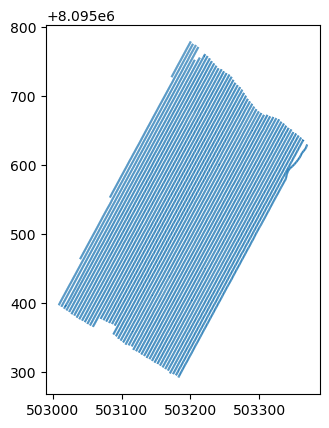

In [50]:
segmentos_lote.plot()

In [51]:
# 1. Configuración de colores (igual que antes)
colores_por_categoria = {
    '1) <5 - OPTIMO': '#228B22',
    '2) 5 a 10 - ACEPTABLE': '#9ACD32',
    '3) 10 a 15 - RIESGO MODERADO': '#FFFF00',
    '4) >15 - RIESGO ALTO': '#FF0000'
}

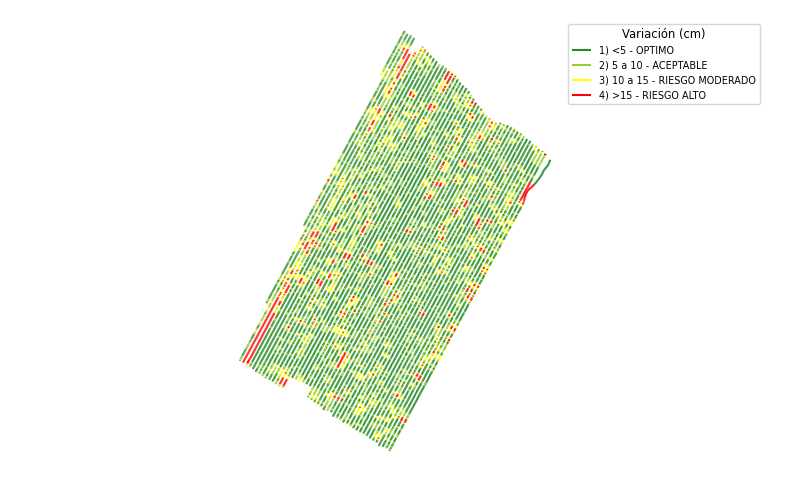

In [52]:
# 1. CONFIGURACIÓN DE DIMENSIONES (1000x600 px)
ancho_px, alto_px = 1000, 600
mi_dpi = 100 

# Creamos la figura: 10x6 pulgadas a 100 DPI = 1000x600 px
fig, ax = plt.subplots(figsize=(ancho_px / mi_dpi, alto_px / mi_dpi))

# 2. CALCULAR EL MARCO (Zoom y centrado para 10:6)
minx, miny, maxx, maxy = segmentos_lote.total_bounds
centro_x = (minx + maxx) / 2
centro_y = (miny + maxy) / 2

ancho_lote = maxx - minx
alto_lote = maxy - miny

# Ajustamos el rango considerando la nueva relación de aspecto (1.66)
# El factor 1.1 añade un 10% de margen de seguridad
rango_visual = max(ancho_lote, alto_lote * (ancho_px / alto_px)) * 1.1

# 3. GRAFICAR
for categoria, data in segmentos_lote.groupby('categoria_variacion'):
    color = colores_por_categoria.get(categoria, 'black')
    data.plot(ax=ax, color=color, label=categoria, linewidth=1.5)

# 4. FORZAR ENCUADRE CENTRADO PROPORCIONAL
ax.set_xlim(centro_x - rango_visual / 2, centro_x + rango_visual / 2)
ax.set_ylim(centro_y - (rango_visual * (alto_px / ancho_px)) / 2, 
            centro_y + (rango_visual * (alto_px / ancho_px)) / 2)

# Configuración estética
ax.set_aspect('equal') # Mantiene la forma real del lote
ax.axis('off')         # Limpia el mapa de coordenadas

# 5. LEYENDA (Pequeña y arriba a la derecha)
ax.legend(
    title="Variación (cm)", 
    loc='upper right', 
    bbox_to_anchor=(0.98, 0.98), # Posición casi en el borde superior derecho
    fontsize='x-small',          # Letra pequeña
    title_fontsize='small', 
    frameon=True
)

# 6. GUARDADO EXACTO
# bbox_inches=None es vital para no alterar los 1000x600 píxeles
plt.savefig("map_1000x600.png", dpi=mi_dpi, bbox_inches=None)

plt.show()

In [53]:
def generar_tabla(segmentos):
    """
    Recibe un GeoDataFrame o DataFrame con las columnas 'distance', 'swathwidth', 
    'id' y 'categoria_variacion' para generar una tabla formateada y con estilos.
    """
    
    # --- 1. CÁLCULOS MATEMÁTICOS ---
    # Calcular área por segmento (ha)
    segmentos['area_ha_calc'] = (segmentos['distance'] * segmentos['swathwidth']) / 10000

    # Agrupar por categoría
    tabla_resumen = segmentos.groupby('categoria_variacion').agg(
        Muestras=('id', 'count'),
        Longitud_m=('distance', 'sum'),
        Area=('area_ha_calc', 'sum')
    ).reset_index()

    # Calcular porcentaje (%)
    total_longitud = tabla_resumen['Longitud_m'].sum()
    tabla_resumen['%'] = (tabla_resumen['Longitud_m'] / total_longitud) * 100

    # Crear fila de Total
    fila_total = pd.DataFrame({
        'categoria_variacion': ['Total'],
        'Muestras': [tabla_resumen['Muestras'].sum()],
        'Longitud_m': [total_longitud],
        '%': [100.0],
        'Area': [tabla_resumen['Area'].sum()]
    })

    # Unir y Renombrar
    df_agrupado = pd.concat([tabla_resumen, fila_total], ignore_index=True)
    df_display = df_agrupado.rename(columns={'categoria_variacion': 'Categoria'})

    # --- 2. FORMATEO DE TEXTO ---
    df_display['Longitud (m)'] = df_display['Longitud_m'].map('{:,.2f}'.format)
    df_display['Area'] = df_display['Area'].map('{:,.2f}'.format)
    
    # Reordenar columnas finales
    df_display = df_display[['Categoria', 'Muestras', 'Longitud (m)', '%', 'Area']]

    # --- 3. APLICACIÓN DE ESTILOS (STYLER) ---
    colores_dict = {
        '1) <5 - OPTIMO': '#228B22',
        '2) 5 a 10 - ACEPTABLE': '#9ACD32',
        '3) 10 a 15 - RIESGO MODERADO': '#FFFF00',
        '4) >15 - RIESGO ALTO': '#FF0000'
    }

    df_con_estilo = df_display.style

    # A. Barra de datos en % (excluyendo la fila Total)
    idx_final = len(df_display) - 2
    df_con_estilo = df_con_estilo.bar(
        subset=pd.IndexSlice[:idx_final, '%'], 
        color='#90EE90', vmin=0, vmax=100, align='left'
    )

    # B. Formato de porcentaje visual
    df_con_estilo = df_con_estilo.format({'%': '{:.2f}%'})

    # C. Función interna para colores de categoría
    def estilo_categoria(val):
        if val in colores_dict:
            bg = colores_dict[val]
            text = 'black' if bg == '#FFFF00' else 'white'
            return f'background-color: {bg}; color: {text}; font-weight: bold; text-align: left;'
        return 'text-align: left;'

    df_con_estilo = df_con_estilo.map(estilo_categoria, subset=['Categoria'])

    # D. Bordes y alineación de columnas numéricas
    df_con_estilo = df_con_estilo.set_properties(**{'border': '1px solid black'})
    
    df_con_estilo = df_con_estilo.set_properties(
        subset=['Muestras', 'Longitud (m)', '%', 'Area'], 
        **{'text-align': 'right'}
    )

    # E. Negrita a la fila Total
    def negrita_total(row):
        return ['font-weight: bold' if row['Categoria'] == 'Total' else '' for _ in row]

    df_con_estilo = df_con_estilo.apply(negrita_total, axis=1)

    # F. Estilo de Cabecera
    df_con_estilo = df_con_estilo.set_table_styles([
        {'selector': 'th', 'props': [('font-weight', 'bold'), 
                                     ('border', '1px solid black'), 
                                     ('background-color', '#ADD8E6'), 
                                     ('text-align', 'center')]}
    ])
    df_con_estilo = df_con_estilo.hide(axis='index')

    return df_con_estilo

In [54]:
mi_tabla = generar_tabla(segmentos_lote)
mi_tabla

Categoria,Muestras,Longitud (m),%,Area
1) <5 - OPTIMO,10764,"11,096.97",58.15%,4.99
2) 5 a 10 - ACEPTABLE,5294,"5,346.90",28.02%,2.41
3) 10 a 15 - RIESGO MODERADO,1797,"1,768.20",9.27%,0.80
4) >15 - RIESGO ALTO,952,871.10,4.56%,0.39
Total,18807,"19,083.18",100.00%,8.59


In [55]:
def exportar_a_pdf(segmentos_lote, df_con_estilo, nombre_pdf="Reporte_Lote.pdf"):
    #PLANO DE LOTE
    # 1. CONFIGURACIÓN DE DIMENSIONES (1000x600 px)
    ancho_px, alto_px = 1000, 600
    mi_dpi = 100 
    # Creamos la figura: 10x6 pulgadas a 100 DPI = 1000x600 px
    fig, ax = plt.subplots(figsize=(ancho_px / mi_dpi, alto_px / mi_dpi))
    # 2. CALCULAR EL MARCO (Zoom y centrado para 10:6)
    minx, miny, maxx, maxy = segmentos_lote.total_bounds
    centro_x = (minx + maxx) / 2
    centro_y = (miny + maxy) / 2
    ancho_lote = maxx - minx
    alto_lote = maxy - miny
    # Ajustamos el rango considerando la nueva relación de aspecto (1.66)
    # El factor 1.1 añade un 10% de margen de seguridad
    rango_visual = max(ancho_lote, alto_lote * (ancho_px / alto_px)) * 1.1
    # 3. GRAFICAR
    for categoria, data in segmentos_lote.groupby('categoria_variacion'):
        color = colores_por_categoria.get(categoria, 'black')
        data.plot(ax=ax, color=color, label=categoria, linewidth=1.5)
    # 4. FORZAR ENCUADRE CENTRADO PROPORCIONAL
    ax.set_xlim(centro_x - rango_visual / 2, centro_x + rango_visual / 2)
    ax.set_ylim(centro_y - (rango_visual * (alto_px / ancho_px)) / 2, 
                centro_y + (rango_visual * (alto_px / ancho_px)) / 2)

    # Configuración estética
    ax.set_aspect('equal') # Mantiene la forma real del lote
    ax.axis('off')         # Limpia el mapa de coordenadas
    # 5. LEYENDA (Pequeña y arriba a la derecha)
    #ax.legend(
    #    title="Variación (cm)", 
    #    loc='upper right', 
    #    bbox_to_anchor=(0.98, 0.98), # Posición casi en el borde superior derecho
    #    fontsize='x-small',          # Letra pequeña
    #    title_fontsize='small', 
    #    frameon=True
    #)
    # 6. GUARDADO EXACTO
    # bbox_inches=None es vital para no alterar los 1000x600 píxeles
    temp_plano = "temp_map.png"
    plt.savefig(temp_plano, dpi=mi_dpi, bbox_inches=None)
    
    #====================================================================
    #TABLA DE DATOS
    # --- 1. GUARDAR EL STYLER COMO IMAGEN TEMPORAL ---
    temp_tabla = "temp_tabla.png"
    dfi.export(df_con_estilo, temp_tabla)

    # --- 2. CREAR EL PDF EN ORIENTACIÓN HORIZONTAL ---
    # Usamos landscape(letter) para rotar la hoja
    c = canvas.Canvas(nombre_pdf, pagesize=landscape(letter))
    ancho_p, alto_p = landscape(letter) # Ahora ancho_p es ~792 y alto_p es ~612

    # --- INSERTAR PLANO DE LOTE
    c.drawImage(temp_plano, 0, 40, width=11*inch, preserveAspectRatio=True)
    
    # --- INSERTAR LA TABLA EN LA ESQUINA INFERIOR IZQUIERDA ---
    # Al ser horizontal, tienes más espacio a lo ancho si deseas aumentar el 'width'
    c.drawImage(temp_tabla, 1*28.35, -0.5*28.35, width=5.0*inch, preserveAspectRatio=True)

    # Título del Reporte (Centrado en el nuevo ancho)
    c.setFont("Helvetica-Bold", 16)
    c.drawCentredString(ancho_p/2, alto_p - 40, "Analisis de Paralelismo")
    c.setFont("Helvetica-Bold", 14)
    c.drawCentredString(ancho_p/2, alto_p - 60, "Propiedad: CAMPODULCE")
    c.setFont("Helvetica-Bold", 14)
    c.drawCentredString(ancho_p/2, alto_p - 80, "Lote: EP-L33, EP-L34")

    # --- DIBUJAR MARCO NEGRO ---
    margen = 20  # Puntos (aprox 0.7 cm)
    c.setStrokeColorRGB(0, 0, 0) # Asegurar color negro
    c.setLineWidth(1.5)          # Grosor de la línea
    c.rect(margen, margen, ancho_p - 2*margen, alto_p - 2*margen, stroke=1, fill=0)
    
    # Pie de página
    #c.setFont("Helvetica", 8)
    #c.drawString(0.5*inch, 0.25*inch, "Generado automáticamente por Sistema de Monitoreo.")

    # Guardar PDF
    c.showPage()
    c.save()

    # --- 3. LIMPIEZA ---
    if os.path.exists(temp_tabla): 
        os.remove(temp_tabla)
    if os.path.exists(temp_plano): 
        os.remove(temp_plano)
        
    print(f"PDF generado con éxito (Horizontal): {nombre_pdf}")

PDF generado con éxito (Horizontal): Reporte_Lote.pdf


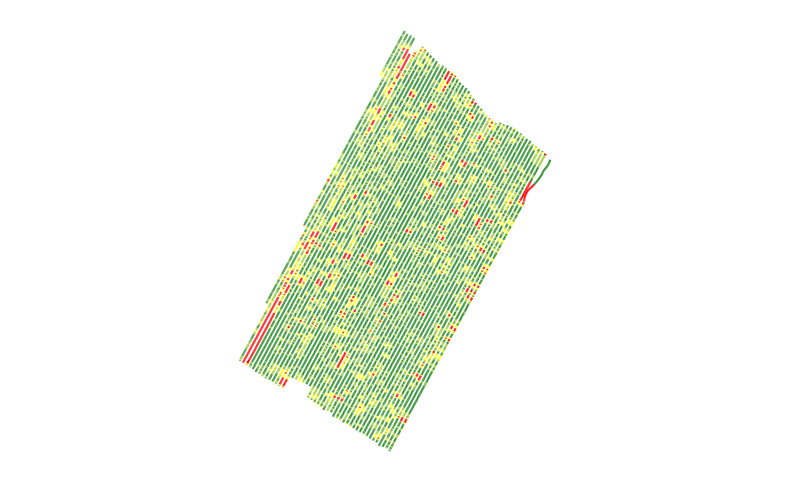

In [56]:
# USO:
exportar_a_pdf(segmentos_lote, mi_tabla)